# IFB 04–06 — Demand, Calendar, Weather & Feature Assembly

Construct the leakage-safe model-ready feature matrix from source-like operational information.

In [1]:
# Import libraries
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while (
    not (PROJECT_ROOT / "src").exists()
    and PROJECT_ROOT != PROJECT_ROOT.parent
):
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "inference_feature_builder.yaml"
)

print("Project root:", PROJECT_ROOT)
print("IFB config:", CONFIG_PATH)


Project root: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk
IFB config: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\configs\inference_feature_builder.yaml


In [3]:
# Import module for running inference_feature_builder
from src.ontario_peak_risk.inference_feature_builder.io import (
    load_ifb_config,
    load_project_history,
    load_operational_updates,
    combine_observed_history,
    latest_weather_forecast_for_origin,
)
from src.ontario_peak_risk.inference_feature_builder.builder import (
    build_feature_matrix,
)
from src.ontario_peak_risk.inference_feature_builder.plotting import (
    lag_profile_plot,
)

### Define the Origin Time for forecasting
- This is the date from which consumption for the next 24 hours is forecasted.
- This value must be changed according with the requirement

In [4]:
# Define the Origin time and FSAs
Origin_Time = "2026-03-25 23:00:00"

In [5]:
# Generate inputs for the models
config, project_root = load_ifb_config(CONFIG_PATH)
FORECAST_ORIGIN = pd.Timestamp(Origin_Time)
FSAS = list(config["inference"]["fsas"])

project_history = load_project_history(config, project_root)
updates = load_operational_updates(config, project_root)

observed_history, _ = combine_observed_history(
    project_history,
    updates["demand"],
    updates["weather_history"],
    config,
)

forecast_weather = latest_weather_forecast_for_origin(
    updates["weather_forecasts"],
    FORECAST_ORIGIN,
    FSAS,
    config,
)

generated = build_feature_matrix(
    observed_history,
    forecast_weather,
    FORECAST_ORIGIN,
    FSAS,
    config=config,
)

display(generated.head(30))
print("Rows:", len(generated))
print("Columns:", len(generated.columns))


,fsa,forecast_origin,horizon,target_timestamp,target_hour,target_weekday,target_month,target_is_weekend,target_hour_sin,target_hour_cos,...,origin_rolling_mean_24h,origin_rolling_std_24h,origin_rolling_mean_168h,_rf_origin_rolling_mean_24h,_rf_origin_rolling_std_24h,_rf_origin_rolling_mean_168h,origin__Temp (°C),origin__Rel Hum (%),origin__Stn Press (kPa),origin__reported_premise_count
0,L4T,2026-03-25 23:00:00,1,2026-03-26 00:00:00,0,3,3,0,0.000000e+00,1.000000e+00,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.00,8567.0
1,L4T,2026-03-25 23:00:00,2,2026-03-26 01:00:00,1,3,3,0,2.588190e-01,9.659258e-01,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.00,8567.0
2,L4T,2026-03-25 23:00:00,3,2026-03-26 02:00:00,2,3,3,0,5.000000e-01,8.660254e-01,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.00,8567.0
3,L4T,2026-03-25 23:00:00,4,2026-03-26 03:00:00,3,3,3,0,7.071068e-01,7.071068e-01,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.00,8567.0
4,L4T,2026-03-25 23:00:00,5,2026-03-26 04:00:00,4,3,3,0,8.660254e-01,5.000000e-01,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.00,8567.0
5,L4T,2026-03-25 23:00:00,6,2026-03-26 05:00:00,5,3,3,0,9.659258e-01,2.588190e-01,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.00,8567.0
6,L4T,2026-03-25 23:00:00,7,2026-03-26 06:00:00,6,3,3,0,1.000000e+00,6.123234e-17,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.00,8567.0
7,L4T,2026-03-25 23:00:00,8,2026-03-26 07:00:00,7,3,3,0,9.659258e-01,-2.588190e-01,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.00,8567.0
8,L4T,2026-03-25 23:00:00,9,2026-03-26 08:00:00,8,3,3,0,8.660254e-01,-5.000000e-01,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.00,8567.0
9,L4T,2026-03-25 23:00:00,10,2026-03-26 09:00:00,9,3,3,0,7.071068e-01,-7.071068e-01,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.00,8567.0


Rows: 144
Columns: 28


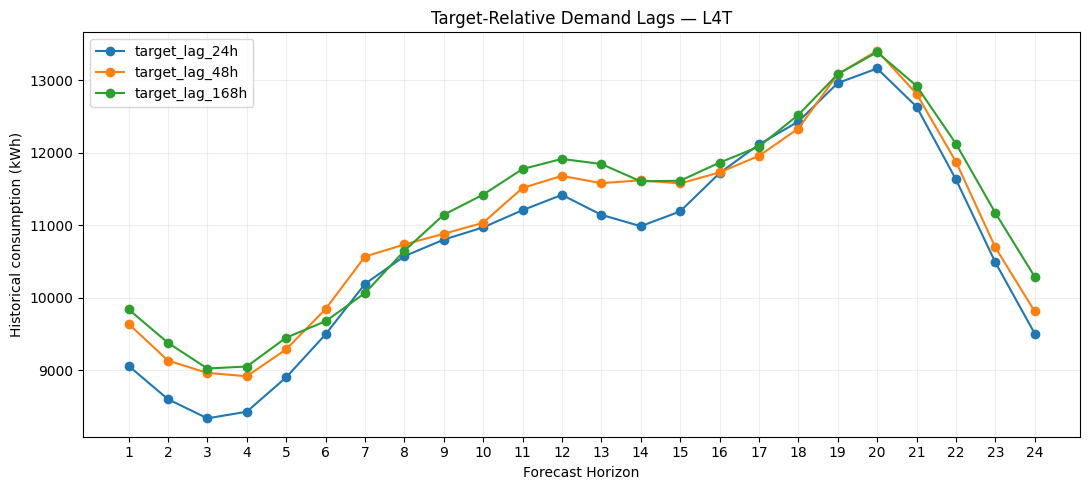

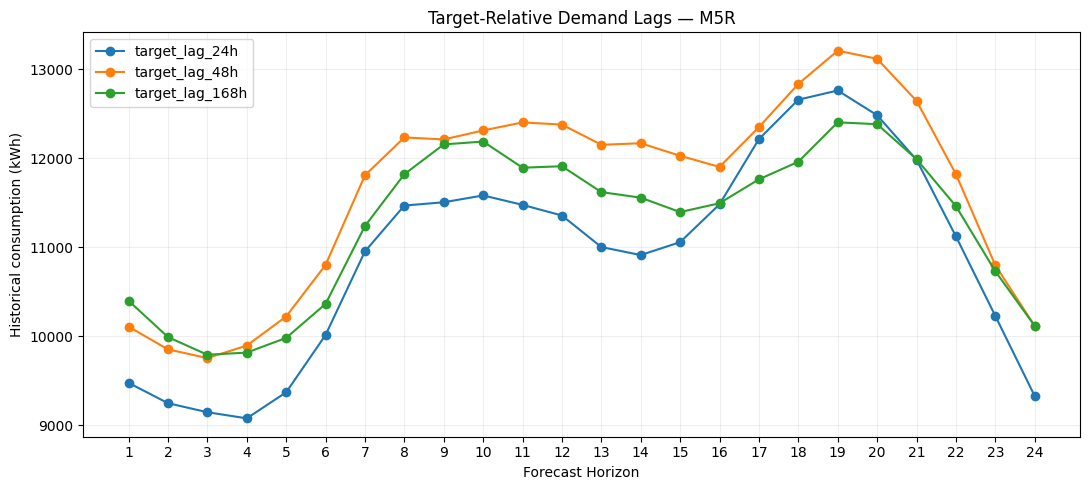

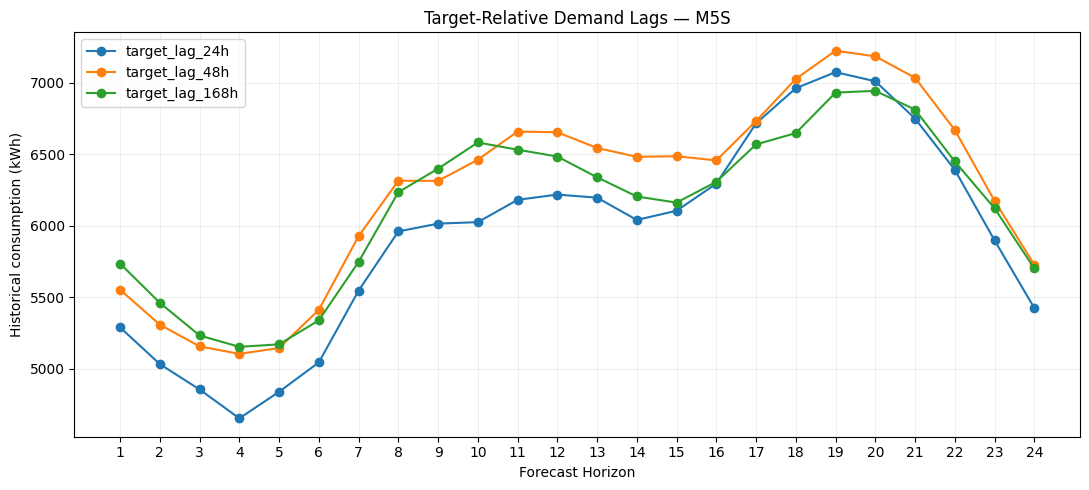

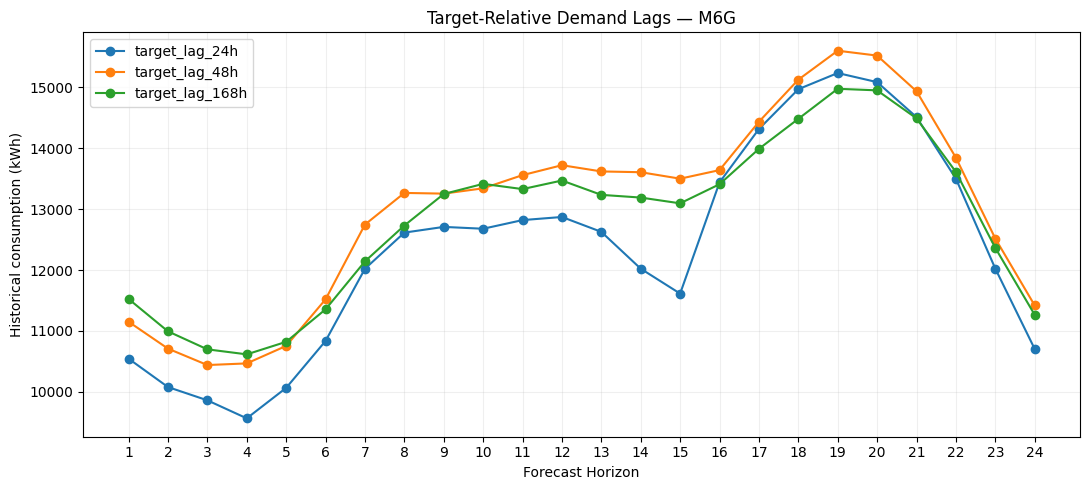

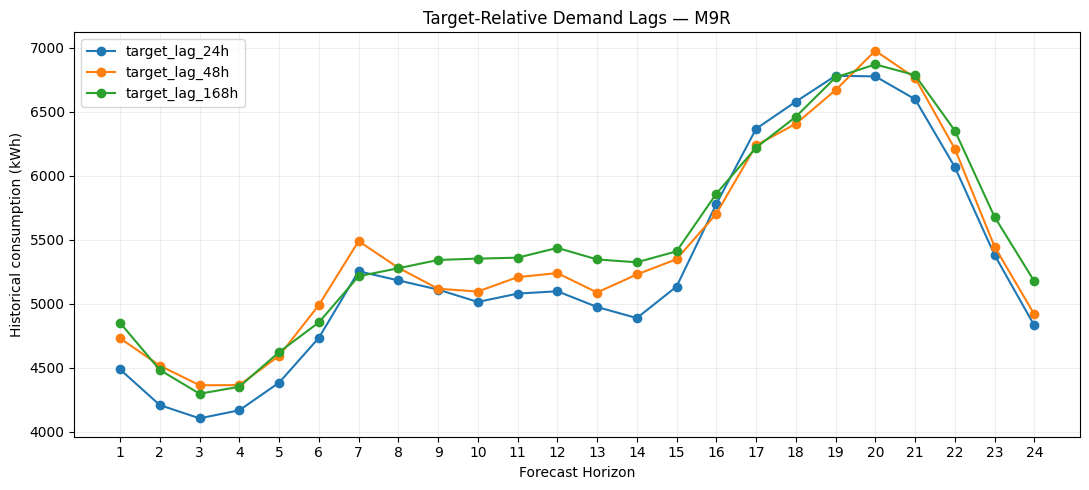

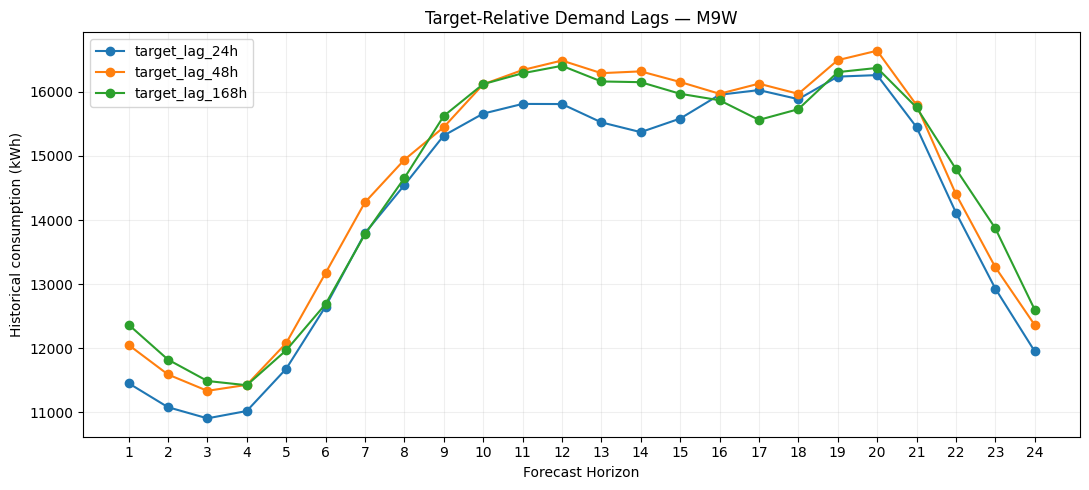

In [6]:
# Plot lag profile for FSA
for fsa in FSAS:
    lag_profile_plot(generated, fsa)
    plt.show()



The lag features are target-relative, while origin rolling statistics use only
observations strictly before the forecast origin. No future observed demand is
used.
